# EfficientNet ASPP CBAM Segmentation

This notebook implements a lightweight food segmentation model inspired by GourmetNet. Instead of fully reproducing the original paper architecture, it keeps the project-friendly EfficientNet-B0 backbone and adds ASPP for multi-scale context, CBAM for channel and spatial attention, and a DeepLab-style upsampling head for mask recovery.

The workflow matches the previous project notebooks: load the fixed split, train with controlled augmentation, save only the best `.pt` checkpoint, evaluate the best checkpoint once on the test set, and display the required analysis plots.

## 1. Libraries

This section imports the required libraries, sets the PyTorch model cache inside the project folder, and uses plain text progress bars for VS Code and Colab-connected kernels.

In [1]:
from pathlib import Path
import json
import math
import os
import random
import time

TORCH_CACHE_DIR = Path.cwd().resolve() / "Torch_Model_Cache"
TORCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageEnhance
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.std import tqdm

print("PyTorch:", torch.__version__)
print("Torch model cache:", TORCH_CACHE_DIR)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)

PyTorch: 2.11.0+cu128
Torch model cache: /content/Torch_Model_Cache
Available device: cuda


## 2. Constants and Paths

This section defines the shared project constants. `BATCH_SIZE` is set to 16 as selected for GPU training. The path search supports both the local project folder and common Colab Drive locations.

In [2]:
def seed_everything(seed=9444):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass


CANDIDATE_ROOTS = [
    Path.cwd().resolve(),
    Path("/content/drive/MyDrive/COMP9444/9444"),
    Path("/content/9444"),
]


def find_project_root():
    for root in CANDIDATE_ROOTS:
        data_root = root / "UECFOODPIX" / "data" / "UECFoodPIX"
        split_file = root / "uecfoodpix_split_train3000_val500.json"
        if data_root.exists() and split_file.exists():
            return root
    checked = "\n".join(str(root) for root in CANDIDATE_ROOTS)
    raise FileNotFoundError(
        "Missing dataset folder or split file. Checked these project roots:\n" + checked
    )


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "UECFOODPIX" / "data" / "UECFoodPIX"
SPLIT_FILE = PROJECT_ROOT / "uecfoodpix_split_train3000_val500.json"
BEST_MODEL_DIR = PROJECT_ROOT / "Best_Model"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
MAX_EPOCHS = 40
SEED = 9444
NUM_WORKERS = 0
IGNORE_BACKGROUND_IN_MIOU = True

seed_everything(SEED)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Split file:", SPLIT_FILE)
print("Best model directory:", BEST_MODEL_DIR)
print(f"Input size: {HEIGHT} x {WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {MAX_EPOCHS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/COMP9444/9444
Data root: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data/UECFoodPIX
Split file: /content/drive/MyDrive/COMP9444/9444/uecfoodpix_split_train3000_val500.json
Best model directory: /content/drive/MyDrive/COMP9444/9444/Best_Model
Input size: 320 x 384
Batch size: 16
Max epochs: 40


## 3. Dataset Split and Class Names

This section loads the fixed train/validation split and the official test set. It also reads class names from `category.txt` when available.

In [3]:
def load_split(split_file):
    with open(split_file, "r", encoding="utf-8") as f:
        split = json.load(f)
    train_key = "train_ids" if "train_ids" in split else "train"
    val_key = "val_ids" if "val_ids" in split else "val"
    train_ids = [str(x) for x in split[train_key]]
    val_ids = [str(x) for x in split[val_key]]
    return train_ids, val_ids


def list_test_ids(data_root):
    test_img_dir = data_root / "test" / "img"
    return sorted(path.stem for path in test_img_dir.glob("*.jpg"))


def load_class_names(data_root, num_classes):
    names = [f"class_{i}" for i in range(num_classes)]
    names[0] = "background"
    candidate_files = [data_root / "category.txt", data_root.parent / "category.txt"]
    category_file = next((path for path in candidate_files if path.exists()), None)
    if category_file is None:
        return names

    with open(category_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.lower().startswith("id"):
                continue
            parts = line.split(maxsplit=1)
            if len(parts) != 2:
                continue
            try:
                label_id = int(parts[0])
            except ValueError:
                continue
            if 0 <= label_id < num_classes:
                names[label_id] = parts[1]
    return names


train_ids, val_ids = load_split(SPLIT_FILE)
test_ids = list_test_ids(DATA_ROOT)
CLASS_NAMES = load_class_names(DATA_ROOT, NUM_CLASSES)

print(f"Train images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")
print(f"Test images: {len(test_ids)}")
print("First classes:", CLASS_NAMES[:10])

Train images: 3000
Validation images: 500
Test images: 1000
First classes: ['background', 'rice', 'eels on rice', 'pilaf', "chicken-'n'-egg on rice", 'pork cutlet on rice', 'beef curry', 'sushi', 'chicken rice', 'fried rice']


## 4. Dataset and Augmentation

This section defines the segmentation dataset. Augmentation is applied only to the training split. It is intentionally moderate, because the model still needs to learn clean food boundaries before heavy augmentation is useful.

In [4]:
RESAMPLE_BILINEAR = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
RESAMPLE_NEAREST = Image.Resampling.NEAREST if hasattr(Image, "Resampling") else Image.NEAREST

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

AUGMENTATION_CONFIG = {
    "horizontal_flip_prob": 0.5,
    "rotation_degrees": 8,
    "crop_scale_min": 0.92,
    "crop_scale_max": 1.0,
    "aspect_min": 0.95,
    "aspect_max": 1.05,
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.10,
}


def random_resized_crop_pair(image, mask, width, height, scale_min, scale_max, aspect_min, aspect_max):
    img_w, img_h = image.size
    area = img_w * img_h

    for _ in range(10):
        target_area = area * random.uniform(scale_min, scale_max)
        aspect = random.uniform(aspect_min, aspect_max)
        crop_w = int(round(math.sqrt(target_area * aspect)))
        crop_h = int(round(math.sqrt(target_area / aspect)))
        if 0 < crop_w <= img_w and 0 < crop_h <= img_h:
            left = random.randint(0, img_w - crop_w)
            top = random.randint(0, img_h - crop_h)
            image = image.crop((left, top, left + crop_w, top + crop_h))
            mask = mask.crop((left, top, left + crop_w, top + crop_h))
            break

    image = image.resize((width, height), RESAMPLE_BILINEAR)
    mask = mask.resize((width, height), RESAMPLE_NEAREST)
    return image, mask


def apply_augmentation(image, mask, config):
    if random.random() < config["horizontal_flip_prob"]:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    degrees = config["rotation_degrees"]
    if degrees > 0:
        angle = random.uniform(-degrees, degrees)
        image = image.rotate(angle, resample=RESAMPLE_BILINEAR)
        mask = mask.rotate(angle, resample=RESAMPLE_NEAREST)

    image, mask = random_resized_crop_pair(
        image,
        mask,
        WIDTH,
        HEIGHT,
        config["crop_scale_min"],
        config["crop_scale_max"],
        config["aspect_min"],
        config["aspect_max"],
    )

    if config["brightness"] > 0:
        factor = random.uniform(1 - config["brightness"], 1 + config["brightness"])
        image = ImageEnhance.Brightness(image).enhance(factor)
    if config["contrast"] > 0:
        factor = random.uniform(1 - config["contrast"], 1 + config["contrast"])
        image = ImageEnhance.Contrast(image).enhance(factor)
    if config["saturation"] > 0:
        factor = random.uniform(1 - config["saturation"], 1 + config["saturation"])
        image = ImageEnhance.Color(image).enhance(factor)

    return image, mask


class FoodSegmentationDataset(Dataset):
    def __init__(self, data_root, image_ids, split, augment=False, width=WIDTH, height=HEIGHT, augmentation_config=None):
        self.data_root = Path(data_root)
        self.image_ids = [str(x) for x in image_ids]
        self.split = split
        self.augment = augment
        self.width = width
        self.height = height
        self.augmentation_config = augmentation_config or AUGMENTATION_CONFIG

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image_path = self.data_root / self.split / "img" / f"{image_id}.jpg"
        mask_path = self.data_root / self.split / "mask" / f"{image_id}.png"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)
        if mask.mode != "L":
            mask = mask.split()[0]

        if self.augment:
            image, mask = apply_augmentation(image, mask, self.augmentation_config)
        else:
            image = image.resize((self.width, self.height), RESAMPLE_BILINEAR)
            mask = mask.resize((self.width, self.height), RESAMPLE_NEAREST)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array.transpose(2, 0, 1))
        image_tensor = (image_tensor - IMAGENET_MEAN) / IMAGENET_STD

        mask_array = np.asarray(mask, dtype=np.int64)
        mask_array = np.where((0 <= mask_array) & (mask_array < NUM_CLASSES), mask_array, 0)
        mask_tensor = torch.from_numpy(mask_array).long()

        return image_tensor, mask_tensor


train_dataset = FoodSegmentationDataset(DATA_ROOT, train_ids, "train", augment=True)
val_dataset = FoodSegmentationDataset(DATA_ROOT, val_ids, "train", augment=False)
test_dataset = FoodSegmentationDataset(DATA_ROOT, test_ids, "test", augment=False)

print("Dataset objects ready.")
print("Augmentation config:", AUGMENTATION_CONFIG)

Dataset objects ready.
Augmentation config: {'horizontal_flip_prob': 0.5, 'rotation_degrees': 8, 'crop_scale_min': 0.92, 'crop_scale_max': 1.0, 'aspect_min': 0.95, 'aspect_max': 1.05, 'brightness': 0.12, 'contrast': 0.12, 'saturation': 0.1}


## 5. Metrics, Class Weights, and Plots

This section defines segmentation metrics and visualizations. Class weights are computed from the training masks to reduce dominance from background and frequent large regions.

In [5]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def make_loader(dataset, shuffle):
    generator = torch.Generator()
    generator.manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator if shuffle else None,
    )


def compute_confusion_matrix(preds, targets, num_classes=NUM_CLASSES):
    preds = preds.detach().view(-1).to(torch.int64).cpu()
    targets = targets.detach().view(-1).to(torch.int64).cpu()
    valid = (targets >= 0) & (targets < num_classes)
    indices = num_classes * targets[valid] + preds[valid]
    matrix = torch.bincount(indices, minlength=num_classes * num_classes)
    return matrix.reshape(num_classes, num_classes).numpy()


def metrics_from_confusion(confusion, ignore_background=IGNORE_BACKGROUND_IN_MIOU):
    confusion = confusion.astype(np.float64)
    true_positive = np.diag(confusion)
    support = confusion.sum(axis=1)
    predicted = confusion.sum(axis=0)
    union = support + predicted - true_positive
    accuracy = true_positive.sum() / max(confusion.sum(), 1.0)
    iou = np.divide(true_positive, union, out=np.full_like(true_positive, np.nan), where=union > 0)
    start = 1 if ignore_background else 0
    valid_iou = iou[start:][~np.isnan(iou[start:])]
    miou = float(valid_iou.mean()) if len(valid_iou) else 0.0
    return {"accuracy": float(accuracy), "miou": miou, "iou_per_class": iou}


def compute_class_weights(data_root, image_ids, split="train", num_classes=NUM_CLASSES):
    counts = np.zeros(num_classes, dtype=np.float64)
    for image_id in tqdm(
        image_ids,
        desc="Class weights",
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    ):
        mask_path = Path(data_root) / split / "mask" / f"{image_id}.png"
        mask = Image.open(mask_path)
        if mask.mode != "L":
            mask = mask.split()[0]
        mask_array = np.asarray(mask, dtype=np.int64)
        mask_array = mask_array[(0 <= mask_array) & (mask_array < num_classes)]
        unique, unique_counts = np.unique(mask_array, return_counts=True)
        counts[unique] += unique_counts

    counts = np.maximum(counts, 1.0)
    freq = counts / counts.sum()
    weights = 1.0 / np.sqrt(freq)
    foreground_mean = weights[1:].mean()
    weights = weights / foreground_mean
    weights = np.clip(weights, 0.25, 3.0)
    weights[0] = min(weights[0], 0.35)
    return torch.tensor(weights, dtype=torch.float32)


def plot_training_history(history, model_name):
    epochs = [item["epoch"] for item in history]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(epochs, [item["train_loss"] for item in history], label="Train loss")
    axes[0].plot(epochs, [item["val_loss"] for item in history], label="Validation loss")
    axes[0].set_title(f"{model_name}: Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(epochs, [item["train_accuracy"] for item in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [item["val_accuracy"] for item in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [item["train_miou"] for item in history], label="Train mIoU")
    axes[1].plot(epochs, [item["val_miou"] for item in history], label="Validation mIoU")
    axes[1].set_title(f"{model_name}: Accuracy and mIoU")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def normalized_confusion(confusion):
    cm = np.asarray(confusion, dtype=np.float64)
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)


def plot_overall_confusion(confusion, title):
    normalized = normalized_confusion(confusion)
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
    ticks = np.arange(0, NUM_CLASSES, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_class_subset_heatmap(confusion, class_indices, title):
    normalized = normalized_confusion(confusion)
    subset = normalized[np.ix_(class_indices, class_indices)]
    labels = [CLASS_NAMES[index] for index in class_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(subset, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=70, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)), labels=labels, fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def best_worst_class_indices(confusion, top_k=10):
    stats = metrics_from_confusion(confusion)
    per_class_iou = stats["iou_per_class"]
    support = np.asarray(confusion).sum(axis=1)
    valid = support > 0
    valid[0] = False
    valid_indices = np.where(valid)[0]
    ordered = valid_indices[np.argsort(per_class_iou[valid_indices])]
    worst = ordered[:top_k].tolist()
    best = ordered[-top_k:][::-1].tolist()
    return best, worst, per_class_iou, support


def print_class_iou_table(title, indices, per_class_iou, support):
    print(title)
    for index in indices:
        print(f"{index:3d} {CLASS_NAMES[index]:30s} IoU={float(per_class_iou[index]):.4f} support={int(support[index])}")


def plot_best_worst_heatmaps(confusion, model_name):
    best, worst, per_class_iou, support = best_worst_class_indices(confusion, top_k=10)
    print_class_iou_table("Best 10 classes by test IoU", best, per_class_iou, support)
    print_class_iou_table("Worst 10 classes by test IoU", worst, per_class_iou, support)
    plot_class_subset_heatmap(confusion, best, f"{model_name}: Best 10 classes test heatmap")
    plot_class_subset_heatmap(confusion, worst, f"{model_name}: Worst 10 classes test heatmap")


## 6. Model: EfficientNet-B0 + ASPP + CBAM + Upsampling Head

This section defines the paper-inspired model. EfficientNet-B0 extracts low-level and high-level features. ASPP gathers multi-scale context. CBAM refines important channels and locations. The upsampling head combines low-level detail with high-level semantic features.

In [6]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, dilation=1, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, rates=(1, 2, 4, 6), dropout=0.1):
        super().__init__()
        self.branches = nn.ModuleList([ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0)])
        for rate in rates:
            self.branches.append(ConvBNReLU(in_channels, out_channels, kernel_size=3, padding=rate, dilation=rate))
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0),
        )
        self.project = ConvBNReLU(out_channels * (len(self.branches) + 1), out_channels, kernel_size=1, padding=0, dropout=dropout)

    def forward(self, x):
        size = x.shape[-2:]
        features = [branch(x) for branch in self.branches]
        pooled = self.global_pool(x)
        pooled = F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)
        features.append(pooled)
        return self.project(torch.cat(features, dim=1))


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )

    def forward(self, x):
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1))
        max_pool = self.mlp(F.adaptive_max_pool2d(x, 1))
        return x * torch.sigmoid(avg + max_pool)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        attention = torch.sigmoid(self.conv(torch.cat([avg, max_pool], dim=1)))
        return x * attention


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction=reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = self.channel_attention(x)
        return self.spatial_attention(x)


class EfficientNetASPPCBAM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, dropout=0.1):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features
        self.low_feature_index = 2
        self.aspp = ASPP(1280, 256, rates=(1, 2, 4, 6), dropout=dropout)
        self.cbam = CBAM(256, reduction=16)
        self.low_project = ConvBNReLU(24, 48, kernel_size=1, padding=0)
        self.head = nn.Sequential(
            ConvBNReLU(256 + 48, 192, dropout=dropout),
            ConvBNReLU(192, 128, dropout=dropout * 0.5),
            nn.Conv2d(128, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        low_feature = None
        for index, layer in enumerate(self.encoder):
            x = layer(x)
            if index == self.low_feature_index:
                low_feature = x
        high_feature = self.cbam(self.aspp(x))
        low_feature = self.low_project(low_feature)
        high_feature = F.interpolate(high_feature, size=low_feature.shape[-2:], mode="bilinear", align_corners=False)
        logits = self.head(torch.cat([high_feature, low_feature], dim=1))
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


model_preview = EfficientNetASPPCBAM(pretrained=False)
print(f"EfficientNet-ASPP-CBAM parameters: {sum(p.numel() for p in model_preview.parameters()):,}")
del model_preview

EfficientNet-ASPP-CBAM parameters: 17,626,149


## 7. Loss and Training Helpers

This section uses class-balanced cross-entropy plus soft Dice loss. The encoder and newly added segmentation modules use separate learning rates, because the encoder is pretrained while ASPP, CBAM, and the head must learn from scratch.

In [7]:
class BalancedDiceCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None, dice_weight=1.0, ignore_background_in_dice=True, label_smoothing=0.0, smooth=1.0):
        super().__init__()
        if class_weights is None:
            self.class_weights = None
        else:
            self.register_buffer("class_weights", class_weights)
        self.dice_weight = dice_weight
        self.ignore_background_in_dice = ignore_background_in_dice
        self.label_smoothing = label_smoothing
        self.smooth = smooth

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.class_weights, label_smoothing=self.label_smoothing)
        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        start = 1 if self.ignore_background_in_dice else 0
        probabilities = probabilities[:, start:]
        one_hot = one_hot[:, start:]
        dims = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dims)
        cardinality = torch.sum(probabilities + one_hot, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return ce_loss + self.dice_weight * (1.0 - dice.mean())


def run_one_epoch(model, loader, criterion, device, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_images = 0
    confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    progress = tqdm(
        loader,
        desc="train" if training else "eval",
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    )
    for images, masks in progress:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        amp_enabled = device.type == "cuda"
        with torch.set_grad_enabled(training):
            with torch.autocast(device_type="cuda", enabled=amp_enabled):
                logits = model(images)
                loss = criterion(logits, masks)
            if training:
                if scaler is not None and amp_enabled:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_images += batch_size
        confusion += compute_confusion_matrix(logits.argmax(dim=1), masks)
        progress.set_postfix(loss=f"{total_loss / max(total_images, 1):.4f}")
    metrics = metrics_from_confusion(confusion)
    metrics["loss"] = total_loss / max(total_images, 1)
    metrics["confusion"] = confusion
    return metrics


def set_encoder_trainable(model, trainable):
    for parameter in model.encoder.parameters():
        parameter.requires_grad = trainable


ASPP_CBAM_CONFIG = {
    "encoder_learning_rate": 1e-5,
    "head_learning_rate": 3e-4,
    "weight_decay": 3e-4,
    "dropout": 0.18,
    "dice_weight": 0.8,
    "label_smoothing": 0.05,
    "ignore_background_in_dice": True,
    "freeze_encoder_epochs": 5,
    "early_stopping_patience": 8,
    "scheduler_patience": 3,
    "lr_factor": 0.5,
    "pretrained": True,
    "use_class_weights": True,
}

print("Training config:", ASPP_CBAM_CONFIG)

Training config: {'encoder_learning_rate': 1e-05, 'head_learning_rate': 0.0003, 'weight_decay': 0.0003, 'dropout': 0.18, 'dice_weight': 0.8, 'label_smoothing': 0.05, 'ignore_background_in_dice': True, 'freeze_encoder_epochs': 5, 'early_stopping_patience': 8, 'scheduler_patience': 3, 'lr_factor': 0.5, 'pretrained': True, 'use_class_weights': True}


## 8. Train and Test the Model

This section trains the model, saves the best checkpoint by validation mIoU, then reloads that checkpoint and evaluates the test set once.

Class weights: 100%|██████████| 3000/3000 [00:14<00:00, 200.11it/s]


Class weights ready. Background weight: 0.25


/tmp/ipykernel_31554/2625766292.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


Training EfficientNet-ASPP-CBAM on cuda
Best checkpoint target: /content/drive/MyDrive/COMP9444/9444/Best_Model/EfficientNet_ASPP_CBAM_best_model.pt

Epoch 1/40 | encoder frozen


eval: 100%|██████████| 32/32 [00:40<00:00,  1.25s/it]


...

{'epoch': 38, 'train_loss': 1.632478137334188, 'val_loss': 2.6288624935150144, 'train_accuracy': 0.9419964463975694, 'val_accuracy': 0.781489404296875, 'train_miou': 0.8721196054193034, 'val_miou': 0.442506698215312}
Saved new best model: val_mIoU=0.4425

Epoch 39/40 | encoder trainable


eval: 100%|██████████| 32/32 [00:07<00:00,  4.07it/s]


{'epoch': 39, 'train_loss': 1.6252447280883788, 'val_loss': 2.6060332946777343, 'train_accuracy': 0.9421933892144098, 'val_accuracy': 0.78188759765625, 'train_miou': 0.8730801967111521, 'val_miou': 0.4401559285516559}

Epoch 40/40 | encoder trainable


eval: 100%|██████████| 32/32 [00:07<00:00,  4.02it/s]


{'epoch': 40, 'train_loss': 1.6207722581227622, 'val_loss': 2.6281470069885255, 'train_accuracy': 0.944266859266493, 'val_accuracy': 0.7808729654947917, 'train_miou': 0.8766582313736151, 'val_miou': 0.4339236152689163}
Training finished in 68.4 minutes. Best epoch: 38, best val mIoU: 0.4425


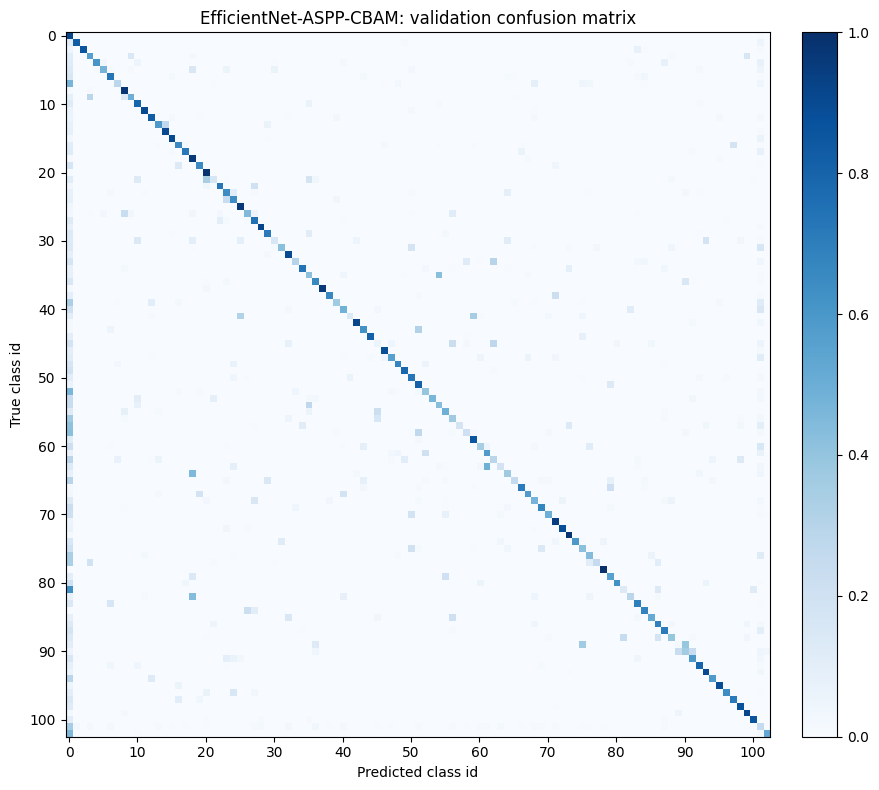

eval: 100%|██████████| 63/63 [00:16<00:00,  3.85it/s]


{'test_loss': 2.777650409698486, 'test_accuracy': 0.7725239095052083, 'test_miou': 0.41428026907569465}


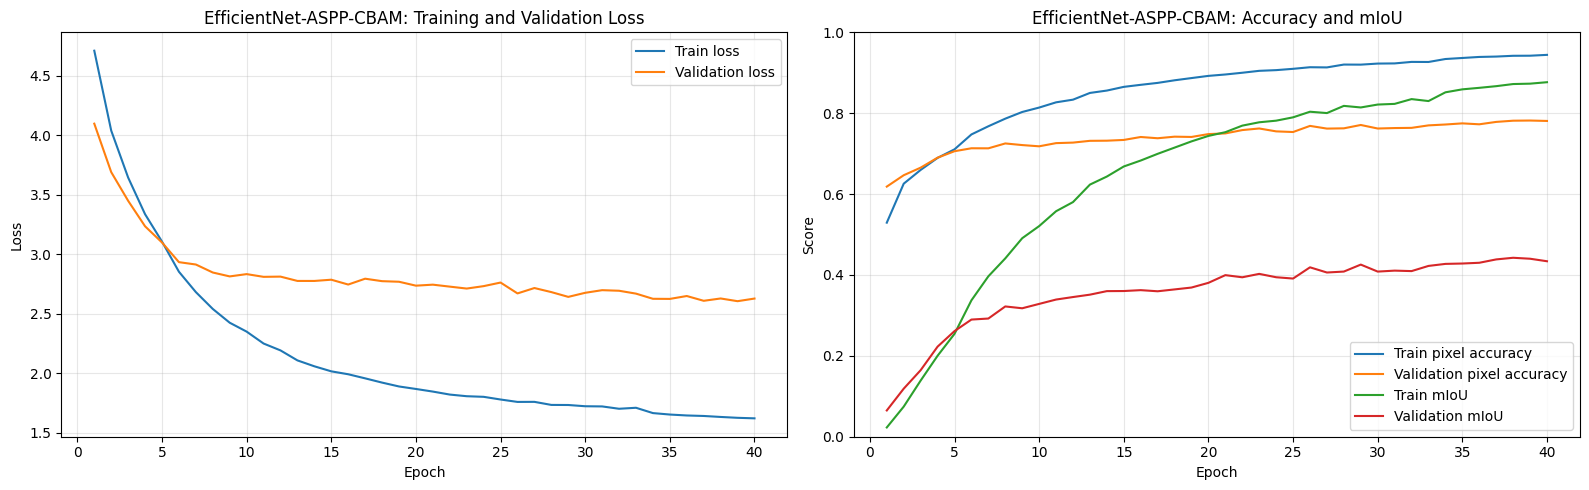

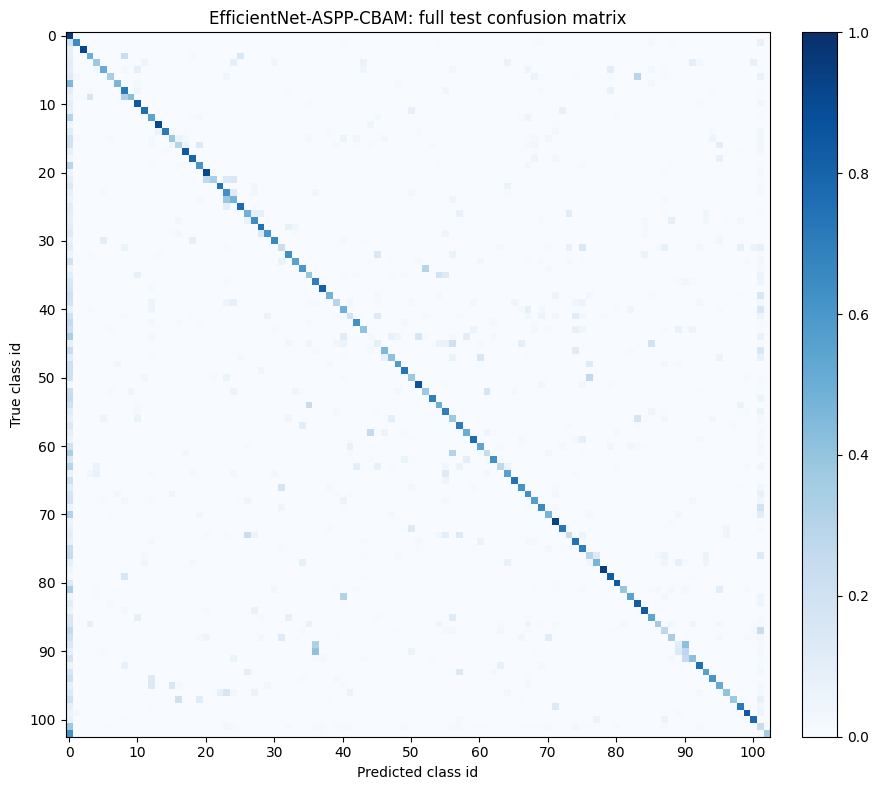

Best 10 classes by test IoU
  2 eels on rice                   IoU=0.8267 support=458314
 78 fish-shaped pancake with bean jam IoU=0.8178 support=366508
 13 croissant                      IoU=0.7795 support=635498
 99 mixed rice                     IoU=0.7433 support=423948
 20 udon noodle                    IoU=0.7076 support=713089
 17 hamburger                      IoU=0.7029 support=1081756
 51 sweet and sour pork            IoU=0.6984 support=459207
 79 shrimp with chill source       IoU=0.6979 support=707674
 37 potage                         IoU=0.6673 support=470193
 80 roast chicken                  IoU=0.6501 support=378905
Worst 10 classes by test IoU
 44 teriyaki grilled fish          IoU=0.0091 support=171224
 45 fried fish                     IoU=0.0451 support=255284
 89 Japanese tofu and vegetable chowder IoU=0.0691 support=343075
 90 pork miso soup                 IoU=0.1357 support=338700
 73 stir-fried beef and peppers    IoU=0.1515 support=303151
 41 ganmodoki      

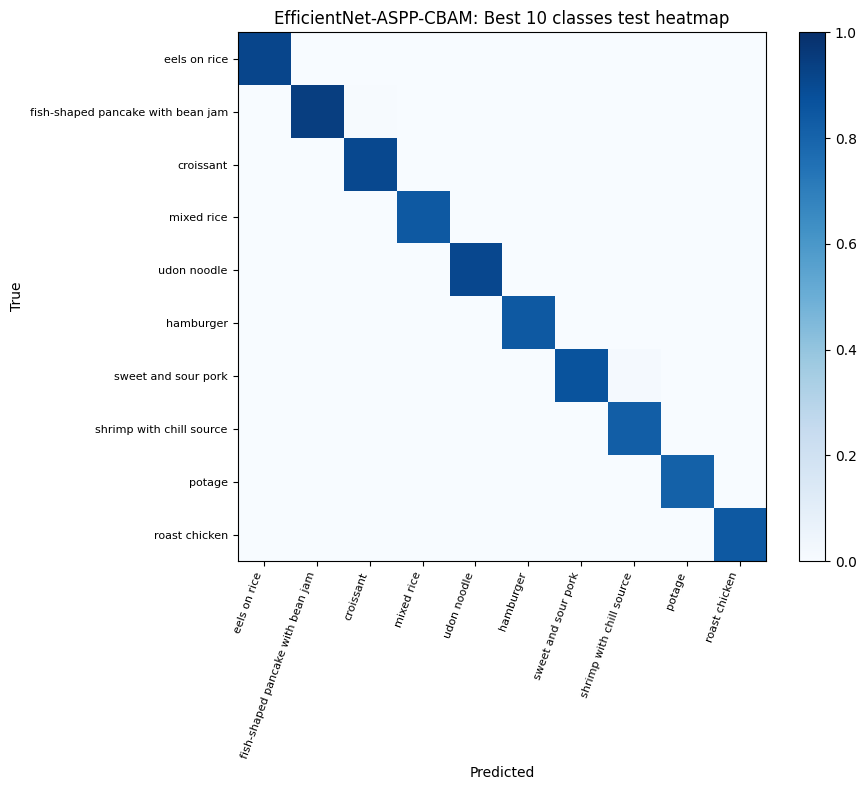

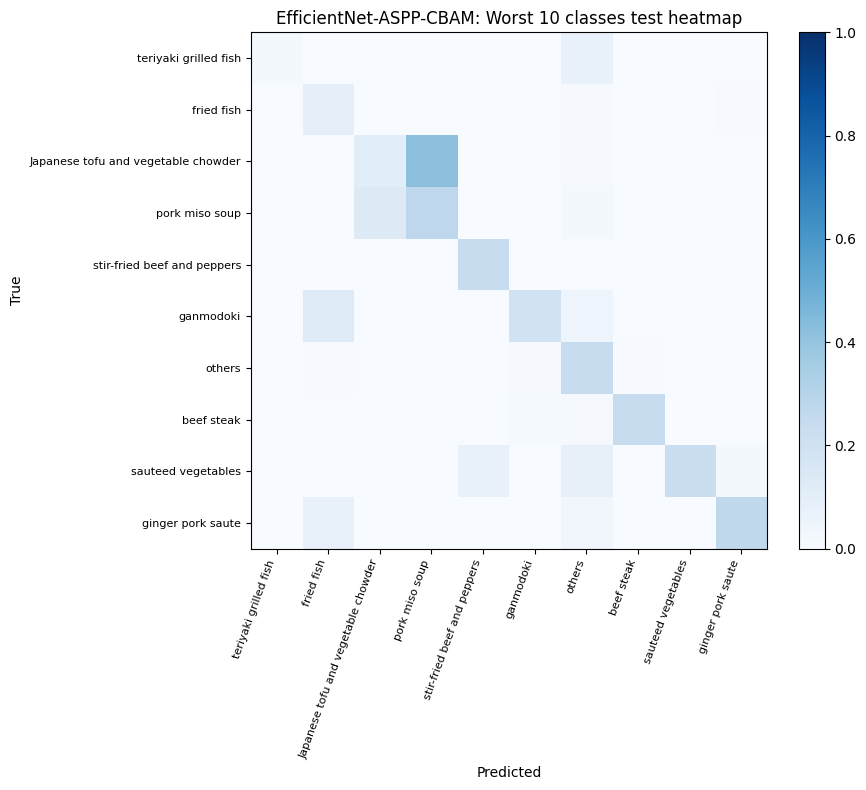

In [8]:
def train_efficientnet_aspp_cbam(config):
    seed_everything(SEED)
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)
    device = get_device()

    class_weights = None
    if config["use_class_weights"]:
        class_weights = compute_class_weights(DATA_ROOT, train_ids, split="train", num_classes=NUM_CLASSES).to(device)
        print("Class weights ready. Background weight:", float(class_weights[0]))

    model = EfficientNetASPPCBAM(pretrained=config["pretrained"], dropout=config["dropout"]).to(device)
    criterion = BalancedDiceCrossEntropyLoss(
        class_weights=class_weights,
        dice_weight=config["dice_weight"],
        ignore_background_in_dice=config["ignore_background_in_dice"],
        label_smoothing=config["label_smoothing"],
    ).to(device)

    head_parameters = [
        *model.aspp.parameters(),
        *model.cbam.parameters(),
        *model.low_project.parameters(),
        *model.head.parameters(),
    ]
    optimizer = torch.optim.AdamW(
        [
            {"params": model.encoder.parameters(), "lr": config["encoder_learning_rate"]},
            {"params": head_parameters, "lr": config["head_learning_rate"]},
        ],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["lr_factor"],
        patience=config["scheduler_patience"],
    )
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    checkpoint_path = BEST_MODEL_DIR / "EfficientNet_ASPP_CBAM_best_model.pt"
    history = []
    best_miou = -1.0
    best_epoch = 0
    best_val_confusion = None
    epochs_without_improvement = 0
    start_time = time.time()

    print(f"Training EfficientNet-ASPP-CBAM on {device}")
    print("Best checkpoint target:", checkpoint_path)

    for epoch in range(1, MAX_EPOCHS + 1):
        freeze_encoder = epoch <= config["freeze_encoder_epochs"]
        set_encoder_trainable(model, not freeze_encoder)
        print(f"\nEpoch {epoch}/{MAX_EPOCHS} | encoder {'frozen' if freeze_encoder else 'trainable'}")
        train_metrics = run_one_epoch(model, train_loader, criterion, device, optimizer=optimizer, scaler=scaler)
        with torch.no_grad():
            val_metrics = run_one_epoch(model, val_loader, criterion, device)
        scheduler.step(val_metrics["miou"])
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "train_miou": train_metrics["miou"],
            "val_miou": val_metrics["miou"],
        }
        history.append(row)
        print(row)
        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            best_epoch = epoch
            epochs_without_improvement = 0
            best_val_confusion = val_metrics["confusion"].copy()
            torch.save(
                {
                    "model_name": "EfficientNet-ASPP-CBAM",
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "input_size": (HEIGHT, WIDTH),
                    "num_classes": NUM_CLASSES,
                    "best_epoch": best_epoch,
                    "best_val_miou": best_miou,
                    "history": history,
                    "augmentation_config": AUGMENTATION_CONFIG,
                    "class_names": CLASS_NAMES,
                },
                checkpoint_path,
            )
            print(f"Saved new best model: val_mIoU={best_miou:.4f}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config["early_stopping_patience"]:
                print(f"Early stopping after {config['early_stopping_patience']} epochs without validation mIoU improvement")
                break

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"Training finished in {elapsed_minutes:.1f} minutes. Best epoch: {best_epoch}, best val mIoU: {best_miou:.4f}")
    if best_val_confusion is not None:
        plot_overall_confusion(best_val_confusion, "EfficientNet-ASPP-CBAM: validation confusion matrix")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    with torch.no_grad():
        test_metrics = run_one_epoch(model, test_loader, criterion, device)

    print({"test_loss": test_metrics["loss"], "test_accuracy": test_metrics["accuracy"], "test_miou": test_metrics["miou"]})
    plot_training_history(history, "EfficientNet-ASPP-CBAM")
    plot_overall_confusion(test_metrics["confusion"], "EfficientNet-ASPP-CBAM: full test confusion matrix")
    plot_best_worst_heatmaps(test_metrics["confusion"], "EfficientNet-ASPP-CBAM")
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_miou": best_miou,
        "test_metrics": test_metrics,
        "checkpoint_path": checkpoint_path,
    }


efficientnet_aspp_cbam_result = train_efficientnet_aspp_cbam(ASPP_CBAM_CONFIG)

## Replot Existing Result Without Retraining

Run this small cell after redefining the plotting functions if you only want to redraw the existing confusion matrices in the U-Net blue-white format without training the model again.


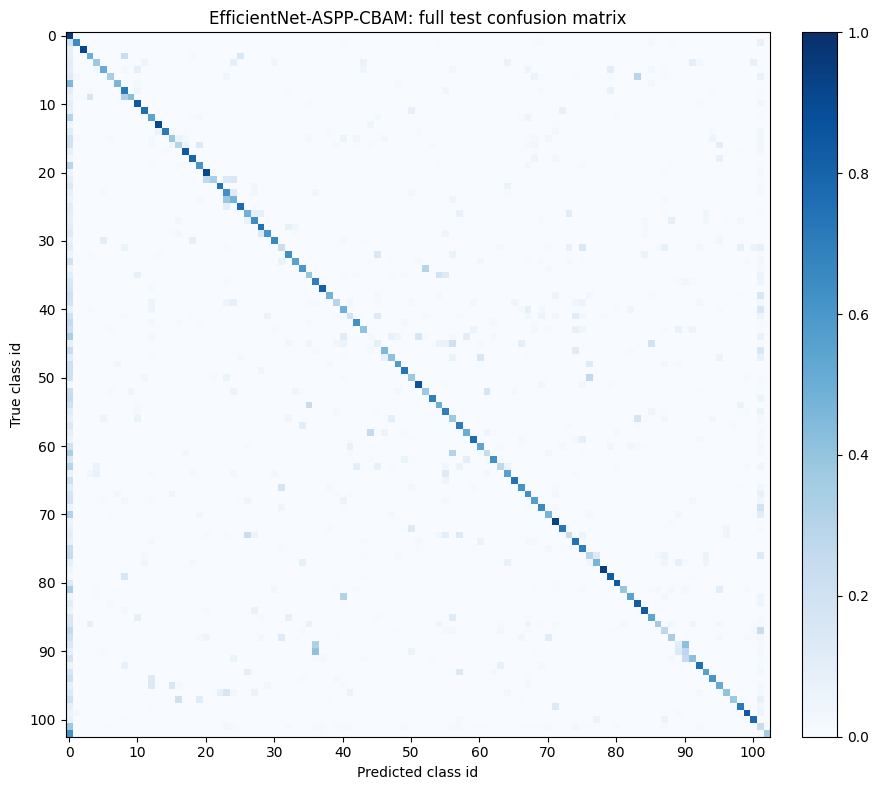

Best 10 classes by test IoU
  2 eels on rice                   IoU=0.8267 support=458314
 78 fish-shaped pancake with bean jam IoU=0.8178 support=366508
 13 croissant                      IoU=0.7795 support=635498
 99 mixed rice                     IoU=0.7433 support=423948
 20 udon noodle                    IoU=0.7076 support=713089
 17 hamburger                      IoU=0.7029 support=1081756
 51 sweet and sour pork            IoU=0.6984 support=459207
 79 shrimp with chill source       IoU=0.6979 support=707674
 37 potage                         IoU=0.6673 support=470193
 80 roast chicken                  IoU=0.6501 support=378905
Worst 10 classes by test IoU
 44 teriyaki grilled fish          IoU=0.0091 support=171224
 45 fried fish                     IoU=0.0451 support=255284
 89 Japanese tofu and vegetable chowder IoU=0.0691 support=343075
 90 pork miso soup                 IoU=0.1357 support=338700
 73 stir-fried beef and peppers    IoU=0.1515 support=303151
 41 ganmodoki      

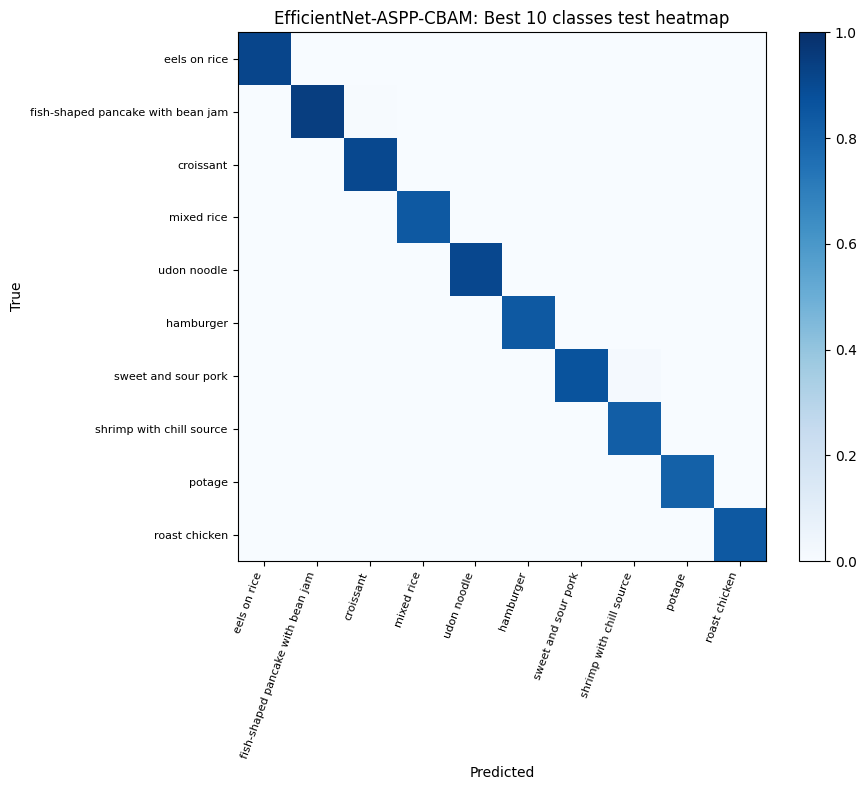

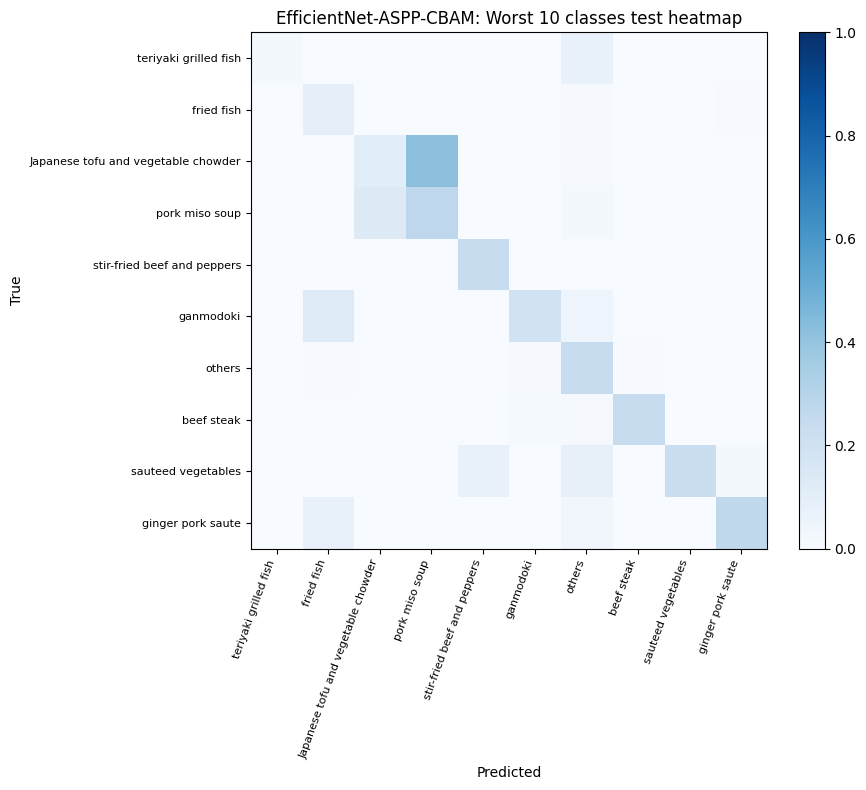

In [9]:
if "efficientnet_aspp_cbam_result" in globals():
    test_confusion = efficientnet_aspp_cbam_result["test_metrics"]["confusion"]
    plot_overall_confusion(test_confusion, "EfficientNet-ASPP-CBAM: full test confusion matrix")
    plot_best_worst_heatmaps(test_confusion, "EfficientNet-ASPP-CBAM")
else:
    print("No existing result found. Run the training cell first, or load a checkpoint and evaluate test once.")


## 9. Result Interpretation

！！！请在此处解释分析结果！！！

Suggested points to discuss after training:

- Whether ASPP improves validation mIoU compared with the EfficientNet baseline and EfficientNet U-Net.
- Whether CBAM helps small food regions and visually ambiguous classes.
- Whether class-balanced loss improves the worst 10 foreground classes.
- Whether train and validation curves show underfitting, overfitting, or stable convergence.
- Whether the test confusion matrix shows repeated mistakes between visually similar food categories.

In [ ]:
# Standalone no-background evaluation for EfficientNet ASPP-CBAM
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.std import tqdm
from torchvision.models import efficientnet_b0

CHECKPOINT_NAME = "EfficientNet_ASPP_CBAM_best_model.pt"  # Rebalanced 改这里
DROPOUT = 0.18  # Rebalanced 改成 0.20

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
NUM_WORKERS = 0

ROOT = Path.cwd().resolve()
if not (ROOT / "Best_Model").exists():
    ROOT = Path("/content/drive/MyDrive/COMP9444/9444")

DATA_ROOT = ROOT / "UECFOODPIX" / "data" / "UECFoodPIX"
BEST_MODEL_DIR = ROOT / "Best_Model"

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class TestDataset(Dataset):
    def __init__(self):
        self.img_dir = DATA_ROOT / "test" / "img"
        self.mask_dir = DATA_ROOT / "test" / "mask"
        self.ids = sorted(p.stem for p in self.img_dir.glob("*.jpg"))
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        sid = self.ids[i]
        image = Image.open(self.img_dir / f"{sid}.jpg").convert("RGB").resize((WIDTH, HEIGHT), Image.Resampling.BILINEAR)
        mask = Image.open(self.mask_dir / f"{sid}.png").resize((WIDTH, HEIGHT), Image.Resampling.NEAREST)
        x = torch.from_numpy((np.asarray(image, dtype=np.float32) / 255.0).copy()).permute(2, 0, 1)
        x = (x - MEAN) / STD
        y = np.asarray(mask)
        if y.ndim == 3:
            y = y[..., 0]
        return x, torch.from_numpy(y.astype(np.int64, copy=True)).long()

class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, dilation=1, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, rates=(1, 2, 4, 6), dropout=0.1):
        super().__init__()
        self.branches = nn.ModuleList([ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0)])
        for rate in rates:
            self.branches.append(ConvBNReLU(in_channels, out_channels, kernel_size=3, padding=rate, dilation=rate))
        self.global_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0))
        self.project = ConvBNReLU(out_channels * (len(self.branches) + 1), out_channels, kernel_size=1, padding=0, dropout=dropout)
    def forward(self, x):
        size = x.shape[-2:]
        features = [branch(x) for branch in self.branches]
        pooled = F.interpolate(self.global_pool(x), size=size, mode="bilinear", align_corners=False)
        return self.project(torch.cat(features + [pooled], dim=1))

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )
    def forward(self, x):
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1))
        max_pool = self.mlp(F.adaptive_max_pool2d(x, 1))
        return x * torch.sigmoid(avg + max_pool)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, max_pool], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()
    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class EfficientNetASPPCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = efficientnet_b0(weights=None).features
        self.low_index = 2
        self.aspp = ASPP(1280, 256, rates=(1, 2, 4, 6), dropout=DROPOUT)
        self.cbam = CBAM(256)
        self.low_project = ConvBNReLU(24, 48, kernel_size=1, padding=0)
        self.head = nn.Sequential(
            ConvBNReLU(304, 192, dropout=DROPOUT),
            ConvBNReLU(192, 128, dropout=DROPOUT),
            nn.Conv2d(128, NUM_CLASSES, 1),
        )

    def forward(self, x):
        out_size = x.shape[-2:]
        low = None
        feat = x
        for i, block in enumerate(self.encoder):
            feat = block(feat)
            if i == self.low_index:
                low = feat
        high = self.cbam(self.aspp(feat))
        high = F.interpolate(high, size=low.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_project(low)
        logits = self.head(torch.cat([high, low], dim=1))
        return F.interpolate(logits, size=out_size, mode="bilinear", align_corners=False)

def update_confusion(cm, pred, target):
    pred = pred.detach().reshape(-1).cpu().long()
    target = target.detach().reshape(-1).cpu().long()
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + pred[valid].clamp(0, NUM_CLASSES - 1)
    cm += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)

def no_background_metrics(cm):
    cm = cm.double().numpy()
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    union = support + predicted - tp
    foreground = np.arange(1, NUM_CLASSES)
    iou = np.divide(tp, union, out=np.full_like(tp, np.nan), where=union > 0)
    return {
        "foreground_accuracy_no_background": float(tp[foreground].sum() / max(support[foreground].sum(), 1)),
        "mIoU_no_background": float(np.nanmean(iou[foreground])),
        "evaluated_foreground_classes": int(np.sum(~np.isnan(iou[foreground]))),
    }

def load_state(path, device):
    ckpt = torch.load(path, map_location=device)
    return ckpt.get("state_dict") or ckpt.get("model_state_dict") or ckpt

@torch.no_grad()
def evaluate():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(TestDataset(), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = EfficientNetASPPCBAM().to(device)
    model.load_state_dict(load_state(BEST_MODEL_DIR / CHECKPOINT_NAME, device))
    model.eval()

    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    for x, y in tqdm(loader, desc="ASPP-CBAM no-bg test", ascii=True):
        x, y = x.to(device), y.to(device)
        update_confusion(cm, model(x).argmax(1), y)

    print(no_background_metrics(cm))

evaluate()

ASPP-CBAM no-bg test: 100%|##########| 63/63 [00:15<00:00,  4.13it/s]

{'foreground_accuracy_no_background': 0.5546326900494963, 'mIoU_no_background': 0.4142258323737621, 'evaluated_foreground_classes': 102}
